<a href="https://colab.research.google.com/github/Rajesh2015/Neural-Networks-Projects/blob/main/CNN%20Projects/Face_Recognization_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision Face Recogonition


### Part A :Build Face Detection System

In [94]:
# Import required lib
import os
import sys
import random

import numpy as np
import pandas as pd
import tensorflow as tf


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

from sklearn.model_selection import train_test_split
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda,SpatialDropout2D
from tensorflow.python.keras import losses
from keras.models import Model, load_model
import keras.optimizers as optimizers
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

### UTILS

In [95]:
def show_image_and_mask_side_by_side(img_arr,mask_arr,model=None):
    """
    Visualizes a sample image, its true mask (label), and optionally the predicted mask.

    Parameters:
    -----------
    img_arr : numpy.ndarray
    mask_arr : numpy.ndarray


    model :  optional (default=None)
    Displays:
    ---------
    A matplotlib figure with:
      - Original input image
      - Ground truth mask
      - Predicted mask (if show_prediction=True)
    """

    if model:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

    ax1.imshow(img_arr)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(mask_arr)
    ax2.set_title("Original Mask")
    ax2.axis("off")

    if model:
        prediction = model.predict(img_arr.reshape(1, 224, 224, 3))[0]
        ax3.imshow(prediction)
        ax3.set_title("Predicted Mask")
        ax3.axis("off")

    plt.tight_layout()
    plt.show()

In [20]:
def augment_np(image, mask):
  """
  Augments a numpy image and mask.
  Parameters:
  -----------
  image : numpy.ndarray
  mask : numpy.ndarray
  Returns:
  --------
  image : numpy.ndarray
  mask : numpy.ndarray
  """
    # Convert to tensors
    image = tf.convert_to_tensor(image)
    mask = tf.convert_to_tensor(mask)

    # Make sure mask has shape (H, W, 1)
    if mask.ndim == 2:
        mask = tf.expand_dims(mask, axis=-1)

    # Apply same augmentations to both
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Return as NumPy arrays
    return image.numpy(), tf.squeeze(mask).numpy()

In [97]:
def set_seeds(seed=42):
  """
  Sets the seeds for reproducibility.
  Parameters:
  -----------
  seed : int, default=42
  """
  os.environ['PYTHONHASHSEED'] = str(seed)
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)

In [76]:
def show_prediction_overlay(image, mask, idx=0, alpha=0.4, resize_to=(128, 128)):
    """
    Displays original image and predicted mask overlay side by side.

    Parameters:
    - image: array of test images (e.g., X_test)
    - mask: array of predicted masks (e.g., pred_test)
    - idx: index of the image to display
    - alpha: transparency of the mask overlay
    - resize_to: size to downscale the images (width, height)
    """
    img = image[idx]
    pred = (mask[idx] > 0.5).astype(np.uint8).squeeze()

    # Resize image and prediction
    img_resized = cv2.resize(img, resize_to)
    if pred.ndim == 2:
        pred_resized = cv2.resize(pred, resize_to, interpolation=cv2.INTER_NEAREST)
    else:
        pred_resized = cv2.resize(pred[..., 0], resize_to, interpolation=cv2.INTER_NEAREST)

    # Create overlay
    overlay = img_resized.copy()
    color = [255, 0, 0]  # Red overlay
    for c in range(3):
        overlay[..., c] = np.where(pred_resized == 1,
                                   overlay[..., c] * (1 - alpha) + alpha * color[c],
                                   overlay[..., c])

    # Plot
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized.astype(np.uint8))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Read data

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
data = np.load('/content/drive/MyDrive/Python Course_shared/Images.npy', allow_pickle=True)

In [23]:
data.shape

(393, 2)

In [100]:
data

array([[array([[[42, 37, 34],
                [56, 51, 48],
                [71, 66, 63],
                ...,
                [23, 33, 34],
                [26, 36, 37],
                [28, 38, 39]],

               [[40, 35, 32],
                [51, 46, 43],
                [64, 59, 56],
                ...,
                [27, 36, 35],
                [24, 33, 32],
                [26, 35, 34]],

               [[43, 38, 35],
                [51, 46, 43],
                [61, 56, 53],
                ...,
                [28, 30, 27],
                [33, 35, 32],
                [35, 37, 34]],

               ...,

               [[56, 47, 40],
                [57, 48, 41],
                [61, 52, 45],
                ...,
                [67, 48, 42],
                [55, 35, 28],
                [60, 40, 33]],

               [[53, 44, 37],
                [54, 45, 38],
                [57, 48, 41],
                ...,
                [59, 40, 34],
                [60, 40, 3

In [101]:
data[0][1]

[{'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063},
   {'x': 0.1723076923076923, 'y': 0.45345345345345345}],
  'imageWidth': 650,
  'imageHeight': 333},
 {'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.583076923076923, 'y': 0.2912912912912913},
   {'x': 0.6584615384615384, 'y': 0.46846846846846846}],
  'imageWidth': 650,
  'imageHeight': 333}]

##### Show Some Image

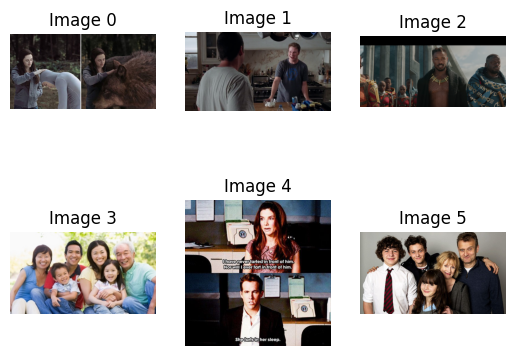

In [102]:
# Show first 5 images
for index in range(0,6,1):
    plt.subplot(2, 3, index + 1)  # Create a 2-row, 3-column grid  plt.imshow(data[index][0])
    plt.imshow(data[index][0])  # Show the image
    plt.axis("off")  # Hide axes
    plt.title(f"Image {index}")  # Add a title

##### Find out Image which have more then 3 channels

In [103]:
for index in range(data.shape[0]):
    img = data[index][0]  # Extract the image

    if len(img.shape) == 2:
        print(f"Image {index} is grayscale (shape: {img.shape})")
    elif img.shape[2] == 4:
        print(f"Image {index} has an alpha channel (RGBA) (shape: {img.shape})")
    elif img.shape[2] != 3:
        print(f"Image {index} has an unexpected number of channels: {img.shape}")

Image 1 has an alpha channel (RGBA) (shape: (697, 1280, 4))
Image 2 has an alpha channel (RGBA) (shape: (291, 600, 4))
Image 39 has an alpha channel (RGBA) (shape: (340, 516, 4))
Image 47 has an alpha channel (RGBA) (shape: (600, 800, 4))
Image 62 has an alpha channel (RGBA) (shape: (312, 750, 4))
Image 134 has an alpha channel (RGBA) (shape: (330, 538, 4))
Image 145 has an alpha channel (RGBA) (shape: (496, 860, 4))
Image 237 has an alpha channel (RGBA) (shape: (379, 505, 4))
Image 251 has an alpha channel (RGBA) (shape: (400, 770, 4))
Image 260 is grayscale (shape: (350, 650))
Image 325 has an alpha channel (RGBA) (shape: (267, 740, 4))
Image 335 has an alpha channel (RGBA) (shape: (281, 600, 4))


In [28]:
IMAGE_HEIGHT=224
IMAGE_WIDTH=224

In [105]:
masks = np.zeros((data.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
image = np.zeros((data.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)

for index in range(data.shape[0]):
    img = data[index][0]

    # Resize first
    img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_CUBIC)

    # Normalize channels: make sure image has exactly 3 channels
    if img.ndim == 2:  # grayscale
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[2] < 3:
        # Pad missing channels with zeros
        pad = np.zeros((img.shape[0], img.shape[1], 3 - img.shape[2]), dtype=img.dtype)
        img = np.concatenate((img, pad), axis=-1)
    elif img.shape[2] > 3:
        img = img[:, :, :3]  # Take only first 3 channels

    image[index] = img

    # Create the mask from annotation
    for box in data[index][1]:
        x1 = int(box["points"][0]['x'] * IMAGE_WIDTH)
        y1 = int(box["points"][0]['y'] * IMAGE_HEIGHT)
        x2 = int(box["points"][1]['x'] * IMAGE_WIDTH)
        y2 = int(box["points"][1]['y'] * IMAGE_HEIGHT)

        # Clamp to valid range
        x1, x2 = max(0, x1), min(IMAGE_WIDTH, x2)
        y1, y2 = max(0, y1), min(IMAGE_HEIGHT, y2)

        masks[index][y1:y2, x1:x2] = 1


In [107]:
size=math.ceil(image.shape[0] * 80 / 100)
print(f"Training {size} and Test Size {image.shape[0]-size}")
X_train=image[:size]
y_train=masks[:size]
X_test=image[size:]
y_test=masks[size:]

Training 315 and Test Size 78


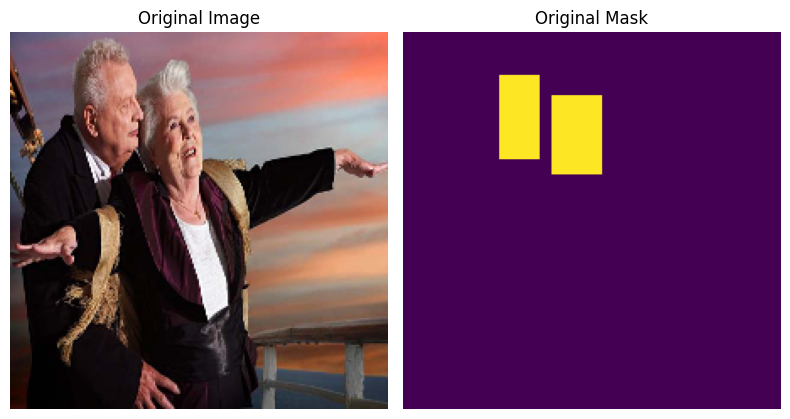

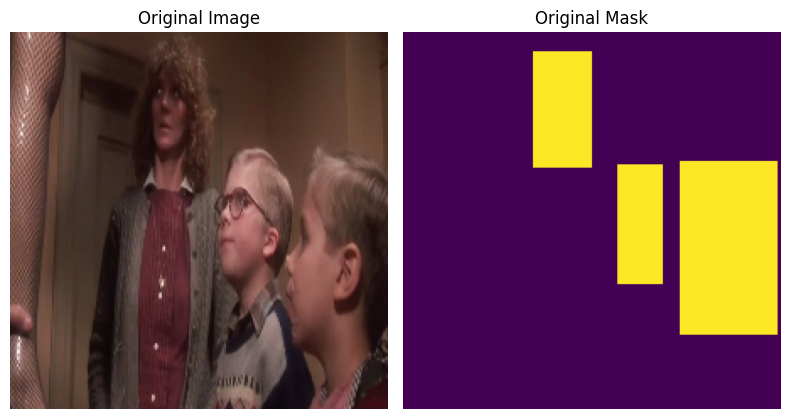

In [108]:
import random
index=random.randint(0,X_train.shape[0])
show_image_and_mask_side_by_side(X_train[index],y_train[index])
index=random.randint(0,X_train.shape[0])
show_image_and_mask_side_by_side(X_train[index],y_train[index])


### Model Building
- Addding ResNet as model with below parameter values
        input_shape: IMAGE_HEIGHT, IMAGE_WIDTH, 3
        include_top: False
        weights: "imagenet"
- UNET architecture layers


#### Custom Loss function

In [109]:
from tensorflow.keras import backend as K

def dice_coeff(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

Resnet50 Model Creation

In [110]:
def unet_resnet50(input_shape=(224, 224, 3), freeze_encoder=True):
    inputs = Input(shape=input_shape)

    # Load ResNet50 with pretrained weights, exclude top layers
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    # Freeze encoder if desired
    if freeze_encoder:
        for layer in base_model.layers:
            layer.trainable = False

    # Extract skip connections
    skips = [
        base_model.get_layer("conv1_relu").output,    # 112x112
        base_model.get_layer("conv2_block3_out").output, # 56x56
        base_model.get_layer("conv3_block4_out").output, # 28x28
        base_model.get_layer("conv4_block6_out").output  # 14x14
    ]
    encoder_output = base_model.get_layer("conv5_block3_out").output  # 7x7

    # Decoder
    x = encoder_output
    for skip in reversed(skips):
        x = Conv2DTranspose(skip.shape[-1], (3, 3), strides=2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)
        x = Dropout(0.3)(x)
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)

    # Final upsampling to match original input size
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    x = Conv2D(1, (1, 1), activation='sigmoid')(x)  # For binary segmentation

    return Model(inputs, x)

In [35]:
# Convert to float32 before preprocessing  resnet preprocessing
X_resNet_train = tf.keras.applications.resnet.preprocess_input(X_train.astype('float32'))
X_resNet_test = tf.keras.applications.resnet.preprocess_input(X_test.astype('float32'))

In [111]:
set_seeds(43)
unet_resnet50_model = unet_resnet50(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_resnet50_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 85,819,841 (327.38 MB)

 Trainable params: 62,232,129 (237.40 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [112]:
unet_resnet50_model.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])

In [38]:
print("X shape:", X_resNet_train.shape)
print("masks shape:", y_train.shape)

X shape: (315, 224, 224, 3)
masks shape: (315, 224, 224)


In [39]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaNs in X_train?", np.isnan(X_train).any())
print("Any NaNs in y_train?", np.isnan(y_train).any())
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

X_train shape: (315, 224, 224, 3)
y_train shape: (315, 224, 224)
Any NaNs in X_train? False
Any NaNs in y_train? False
X_train dtype: uint8
y_train dtype: uint8


In [41]:
checkpoint = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")


In [42]:
unet_resnet50_model.fit(X_train, y_train, epochs=10, batch_size=8, callbacks=[checkpoint, reduce_lr, stop])

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - dice_coeff: 0.1596 - dice_loss: 0.8404 - loss: 1.3931
Epoch 1: loss improved from inf to 1.23990, saving model to model-1.24.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - dice_coeff: 0.1610 - dice_loss: 0.8390 - loss: 1.3893 - learning_rate: 0.0010
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - dice_coeff: 0.3501 - dice_loss: 0.6499 - loss: 1.0087
Epoch 2: loss improved from 1.23990 to 0.87426, saving model to model-0.87.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - dice_coeff: 0.3522 - dice_loss: 0.6478 - loss: 1.0054 - learning_rate: 0.0010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - dice_coeff: 0.5107 - dice_loss: 0.4893 - loss: 0.7691
Epoch 3: loss improved from 0.87426 to 0.69312, saving model to model-0.69.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - dice_coeff: 0.5120 - dice_loss: 0.4880 - loss: 0.7673 - learning_rate: 0.0010
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - dice_

In [43]:
# Evaluate the model.
result_score = unet_resnet50_model.evaluate(X_resNet_test, y_test, batch_size=4, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 529ms/step - dice_coeff: 0.6113 - dice_loss: 0.3887 - loss: 0.6822
Test Loss: 0.7478
Dice Loss: 0.4276
Dice Coefficient: 0.5724


### Observation:
Model performance for test is around .60 which is not that great we will try optimising it

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


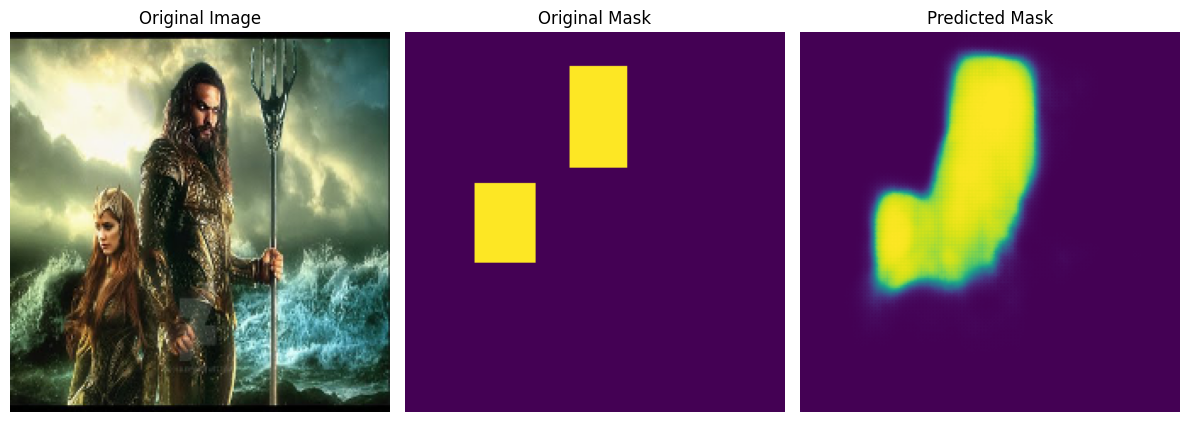

In [44]:
show_image_and_mask_side_by_side(X_test[1],y_test[1],unet_resnet50_model)

####  Data Augomentation


Image Augomentation and Model Creation

In [45]:
X_train_aug = []
y_train_aug = []

for img, mask in zip(X_train, y_train):

    augmented_img, augmented_mask = augment_np(img, mask)
    X_train_aug.append(augmented_img)
    y_train_aug.append(augmented_mask)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

X_train_full = np.concatenate([X_train, X_train_aug], axis=0)
y_train_full = np.concatenate([y_train, y_train_aug], axis=0)

In [46]:
X_train_full.shape

(630, 224, 224, 3)

In [47]:
# Convert to float32 before preprocessing  resnet preprocessing
X_resNet_train_full = tf.keras.applications.resnet.preprocess_input(X_train_full.astype('float32'))


In [ ]:
backend.clear_session()
set_seeds(43)
checkpoint2 = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop2 = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr2 = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")
unet_resnet50_model_2 = unet_resnet50(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_resnet50_model_2.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])
unet_resnet50_model_2.fit(X_resNet_train_full, y_train_full, epochs=10, batch_size=20, callbacks=[checkpoint2, reduce_lr2, stop2])

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - dice_coeff: 0.1771 - dice_loss: 0.8229 - loss: 1.3544
Epoch 1: loss improved from inf to 1.43452, saving model to model-1.43.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - dice_coeff: 0.1775 - dice_loss: 0.8225 - loss: 1.3569 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - dice_coeff: 0.2775 - dice_loss: 0.7225 - loss: 1.0985
Epoch 2: loss improved from 1.43452 to 0.99476, saving model to model-0.99.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - dice_coeff: 0.2791 - dice_loss: 0.7209 - loss: 1.0953 - learning_rate: 0.0010
Epoch 3/10


In [49]:
# Evaluate the model.
result_score = unet_resnet50_model_2.evaluate(X_resNet_test, y_test, batch_size=4, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - dice_coeff: 0.6516 - dice_loss: 0.3484 - loss: 0.6451
Test Loss: 0.6755
Dice Loss: 0.3646
Dice Coefficient: 0.6354


#### Base Model :MobilenetV2

In [50]:
def unet_mobilenetv2(input_shape=(224, 224, 3), freeze_encoder=True):
    inputs = Input(shape=input_shape)

    # Load MobileNetV2 as encoder
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base_model.layers:
            layer.trainable = False

    # Skip connections
    skips = [
        base_model.get_layer('block_1_expand_relu').output,   # 112x112
        base_model.get_layer('block_3_expand_relu').output,   # 56x56
        base_model.get_layer('block_6_expand_relu').output,   # 28x28
        base_model.get_layer('block_13_expand_relu').output   # 14x14
    ]
    encoder_output = base_model.get_layer('block_16_project').output  # 7x7

    # Decoder
    x = encoder_output
    for skip in reversed(skips):
        x = Conv2DTranspose(skip.shape[-1], (3, 3), strides=2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)
        x = Dropout(0.3)(x)
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)

    # Final upsampling and output
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(x)

    return Model(inputs, outputs)


In [51]:
X_mobilenet_train = tf.keras.applications.mobilenet_v2.preprocess_input(X_train.astype('float32'))
X_mobilenet_test = tf.keras.applications.mobilenet_v2.preprocess_input(X_test.astype('float32'))

In [52]:
backend.clear_session()
set_seeds(43)
checkpoint2 = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop2 = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr2 = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")
unet_mobilev2_model = unet_mobilenetv2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_mobilev2_model.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])
unet_mobilev2_model.fit(X_mobilenet_train, y_train, epochs=25, batch_size=8, callbacks=[checkpoint2, reduce_lr2, stop2])

<ipython-input-50-bb599059fa72>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)


Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - dice_coeff: 0.1494 - dice_loss: 0.8506 - loss: 1.3122
Epoch 1: loss improved from inf to 1.24620, saving model to model-1.25.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 374ms/step - dice_coeff: 0.1499 - dice_loss: 0.8501 - loss: 1.3106 - learning_rate: 0.0010
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - dice_coeff: 0.2458 - dice_loss: 0.7542 - loss: 1.1306
Epoch 2: loss improved from 1.24620 to 1.20788, saving model to model-1.21.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 158ms/step - dice_coeff: 0.2462 - dice_loss: 0.7538 - loss: 1.1325 - learning_rate: 0.0010
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - dice_coeff: 0.2130 - dice_loss: 0.7870 - loss: 1.2536
Epoch 3: loss improved from 1.20788 to 1.16617, saving model to model-1.17.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - dice_coeff: 0.2136 - dice_loss: 0.7864 - loss: 1.2515 - learning_rate: 0.0010
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - dic

In [53]:
result_score = unet_mobilev2_model.evaluate(X_mobilenet_test, y_test, batch_size=8, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 354ms/step - dice_coeff: 0.7027 - dice_loss: 0.2973 - loss: 0.5233
Test Loss: 0.5317
Dice Loss: 0.3019
Dice Coefficient: 0.6981


In [58]:
pred_test= unet_mobilev2_model.predict(X_mobilenet_test, verbose=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step


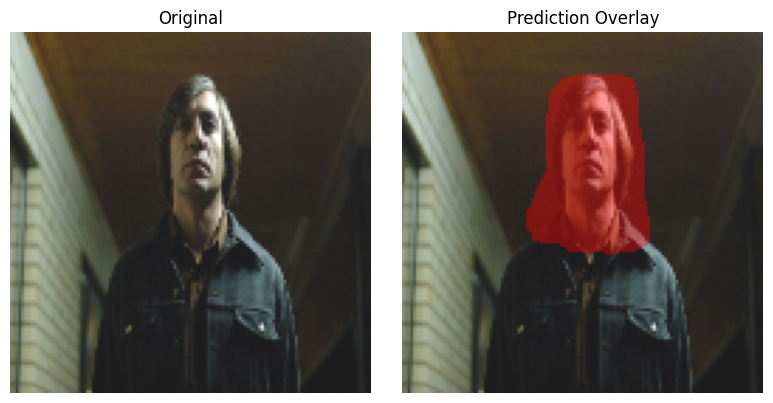

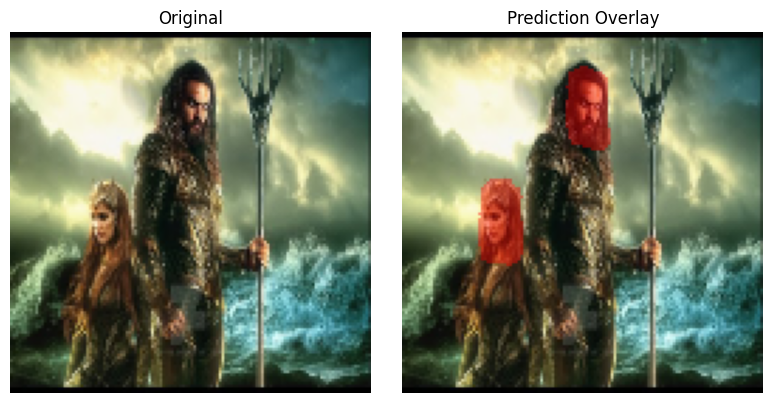

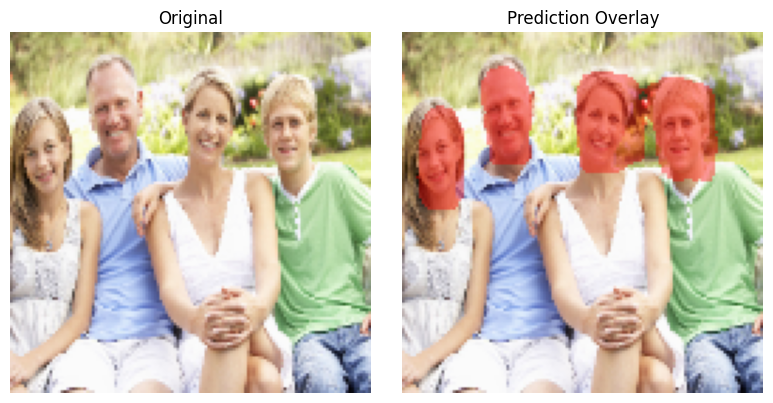

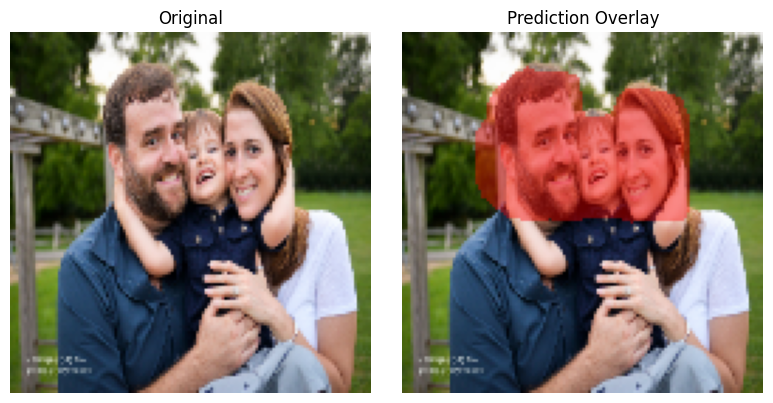

In [91]:
for index in range(4):
    show_prediction_overlay(X_test, pred_test, idx=index)

In [ ]:
predictions